<a href="https://colab.research.google.com/github/anakhaa269/ml-lab/blob/main/exp_3_Ridge_Lasso_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
# Load the diabetes dataset
diabetes = load_diabetes()

In [8]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 353
Testing samples: 89


In [9]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_pred_linear = linear_model.predict(X_test_scaled)

print("Linear Regression:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_linear))
print("R-squared:", r2_score(y_test, y_pred_linear))



Linear Regression:
Mean Squared Error: 2900.1936284934823
R-squared: 0.45260276297191926


In [12]:
ridge = Ridge()

param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

ridge_cv = GridSearchCV(ridge, param_grid, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

best_ridge= ridge_cv.best_estimator_

y_pred_ridge = best_ridge.predict(X_test_scaled)

print("Best alpha for ridge:", ridge_cv.best_params_['alpha'])
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R-squared:", r2_score(y_test, y_pred_ridge))



Best alpha for ridge: 10
MSE: 2875.7787184218428
R-squared: 0.4572109567780849


In [13]:
lasso = Lasso(max_iter=10000)

lasso_cv = GridSearchCV(lasso, param_grid, cv=5)
lasso_cv.fit(X_train_scaled, y_train)

best_lasso = lasso_cv.best_estimator_

y_pred_lasso = best_lasso.predict(X_test_scaled)
print("Best alpha for lasso:", lasso_cv.best_params_['alpha'])
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R-squared:", r2_score(y_test, y_pred_lasso))


Best alpha for lasso: 1
MSE: 2824.568094049959
R-squared: 0.46687670944102466


In [15]:
result = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'MSE': [mean_squared_error(y_test, y_pred_linear),
            mean_squared_error(y_test, y_pred_ridge),
            mean_squared_error(y_test, y_pred_lasso)],
    'R-squared': [r2_score(y_test,y_pred_linear),
                  r2_score(y_test, y_pred_ridge),
                  r2_score(y_test, y_pred_lasso)]
})
print(result)

               Model          MSE  R-squared
0  Linear Regression  2900.193628   0.452603
1              Ridge  2875.778718   0.457211
2              Lasso  2824.568094   0.466877


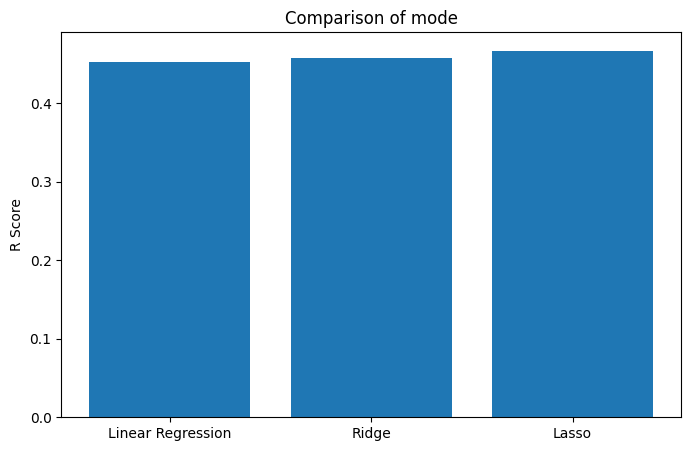

In [17]:
plt.figure(figsize=(8,5))

models = ['Linear Regression', 'Ridge', 'Lasso']
r2_scores = [r2_score(y_test, y_pred_linear),
             r2_score(y_test, y_pred_ridge),
             r2_score(y_test, y_pred_lasso)]
plt.bar(models, r2_scores)
plt.ylabel('R Score')
plt.title('Comparison of mode')
plt.show()